# Day 4 · Notebook 1 — Your first neural network
### ML Bootcamp · Day 4 of 5

**Question:** can a computer tell a **sneaker** from a **sandal**, or a **shirt** from a **T-shirt**, just from a tiny grey picture?

In this notebook you will:
1. Build **one neuron by hand** and play with activation functions *(Part 1)*
2. Meet **Fashion-MNIST**: 70,000 pictures of clothes *(Part 2)*
3. Build, train and test your **first neural network** with Keras *(Part 3)*
4. Find out **what it gets wrong** with a confusion matrix *(Part 4)*
5. Make a network **overfit** — then fix it with **dropout** *(Part 5)*

> 🕐 In class: Parts 1–3 in the first hands-on block, Parts 4–5 in the second.
>
> ⚡ **First:** Runtime → Change runtime type → **T4 GPU** → Save. Everything also works on CPU, just slower.
>
> Run cells in order with **Shift + Enter**. 🧠 = think about it, ✍️ = exercise (solutions at the end).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras import layers
sns.set_theme(style="whitegrid")

keras.utils.set_random_seed(42)   # same random start for everyone -> similar results
print("TensorFlow", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow 2.20.0
GPU available: True


---
## Part 1 · One neuron by hand
A neuron does three things:
1. multiply each input by a **weight** (how important it is),
2. add them up, plus a **bias** (a starting nudge),
3. pass the total through an **activation function** that decides the output.

$$\text{output} = f(w_1x_1 + w_2x_2 + w_3x_3 + b)$$

**Example from the slides — should I go out tonight?**

In [2]:
# inputs: 1 = yes, 0 = no
x = np.array([1,    # sunny?
              1,    # have money?
              1])   # exam tomorrow?

w = np.array([2, 3, -4])   # weights: exam tomorrow pushes strongly towards "stay home"
b = -0.5                   # bias

total = np.dot(w, x) + b   # w1*x1 + w2*x2 + w3*x3 + b
print("Weighted sum =", total)
print("Decision:", "GO OUT 🎉" if total > 0 else "STAY HOME 📚")

Weighted sum = 0.5
Decision: GO OUT 🎉


✍️ **Exercise 1:** change the weight of "exam tomorrow" to **-6**. What is the decision now? What if it isn't sunny?

🧠 Nobody types in the weights of a real network. **Training** finds them automatically from examples.

### Activation functions
The activation decides what the neuron passes on. Three you will meet everywhere:
- **Sigmoid** squashes any number into 0 → 1 (a probability) — this is exactly Day 2's logistic regression.
- **ReLU** keeps positives, turns negatives into 0. Simple and fast — the default for hidden layers.
- **Softmax** (used in the last layer) turns 10 scores into 10 probabilities that add up to 1.

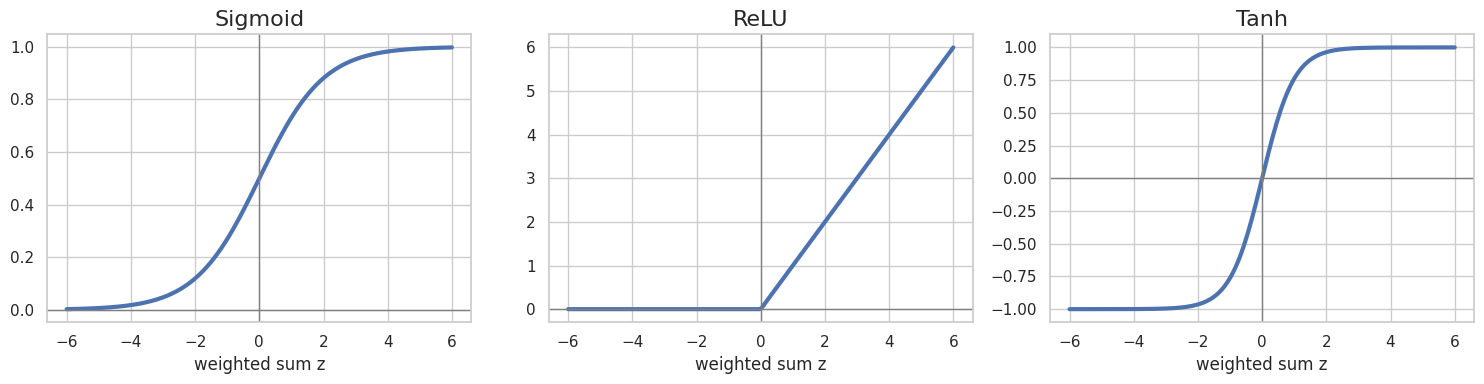

Sigmoid of our 0.5 total: 0.622 -> 62% sure we go out


In [3]:
z = np.linspace(-6, 6, 200)
sigmoid = 1 / (1 + np.exp(-z))
relu = np.maximum(0, z)
tanh = np.tanh(z)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, y, name in zip(axes, [sigmoid, relu, tanh], ["Sigmoid", "ReLU", "Tanh"]):
    ax.plot(z, y, linewidth=3)
    ax.axhline(0, color="grey", lw=1); ax.axvline(0, color="grey", lw=1)
    ax.set_title(name, fontsize=16); ax.set_xlabel("weighted sum z")
plt.tight_layout(); plt.show()

print("Sigmoid of our 0.5 total:", round(1 / (1 + np.exp(-0.5)), 3), "-> 62% sure we go out")

In [4]:
# Softmax: turn raw scores into probabilities
scores = np.array([2.0, 1.0, 0.1])
probs = np.exp(scores) / np.exp(scores).sum()
print("scores       :", scores)
print("probabilities:", probs.round(3), " sum =", probs.sum())

scores       : [2.  1.  0.1]
probabilities: [0.659 0.242 0.099]  sum = 1.0


---
## Part 2 · Meet Fashion-MNIST
**70,000 greyscale pictures** of clothes, each **28 × 28 pixels**, in **10 classes**. Made by Zalando (a fashion website) as a harder replacement for the famous handwritten-digit dataset MNIST.

We download it straight from Zalando's GitHub page (takes a few seconds).

In [5]:
import gzip, urllib.request

BASE = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"

def load_fashion(kind):
    """Download one half (train or t10k) of Fashion-MNIST straight from the official GitHub repo."""
    raw_imgs = urllib.request.urlopen(BASE + f"{kind}-images-idx3-ubyte.gz").read()
    raw_labs = urllib.request.urlopen(BASE + f"{kind}-labels-idx1-ubyte.gz").read()
    imgs = np.frombuffer(gzip.decompress(raw_imgs), np.uint8, offset=16).reshape(-1, 28, 28)
    labs = np.frombuffer(gzip.decompress(raw_labs), np.uint8, offset=8)
    return imgs, labs

X_train_raw, y_train = load_fashion("train")
X_test_raw,  y_test  = load_fashion("t10k")

class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print("Training images:", X_train_raw.shape)   # (60000, 28, 28)
print("Test images:    ", X_test_raw.shape)    # (10000, 28, 28)

Training images: (60000, 28, 28)
Test images:     (10000, 28, 28)


[6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]


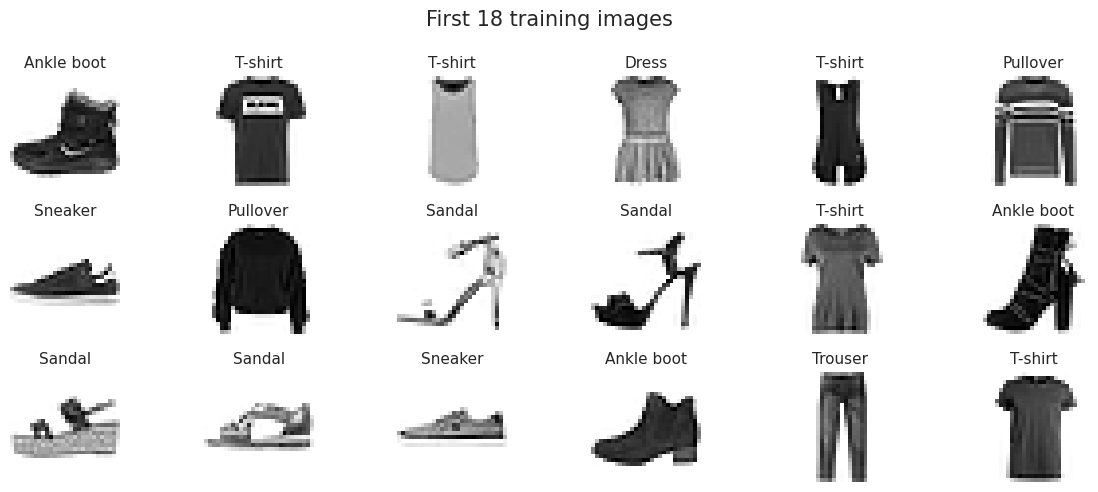

In [6]:
# How many of each class? (perfectly balanced)
print(np.bincount(y_train))

plt.figure(figsize=(12, 5))
for i in range(18):
    plt.subplot(3, 6, i + 1)
    plt.imshow(X_train_raw[i], cmap="gray_r")
    plt.title(class_names[y_train[i]], fontsize=11)
    plt.axis("off")
plt.suptitle("First 18 training images", fontsize=15)
plt.tight_layout(); plt.show()

### An image is just numbers
Each pixel is a number from **0 (black)** to **255 (white)**. Look at the top-left corner of the first image:

In [7]:
print("Label:", class_names[y_train[0]])
print("Shape:", X_train_raw[0].shape, "=", 28 * 28, "numbers")
print(X_train_raw[0][5:15, 5:15])   # a 10 x 10 window of pixels

Label: Ankle boot
Shape: (28, 28) = 784 numbers
[[  0   0   0   0   0   0   0   6   0 102]
 [  0   0   0   0   0   0   0   0   0 155]
 [  0   0   0   0   0   0   1   0  69 207]
 [  0   0   0   0   1   1   1   0 200 232]
 [  0   0   0   0   0   0   0   0 183 225]
 [  0   0   0   0   0   0   0   0 193 228]
 [  0   0   0   0   1   3   0  12 219 220]
 [  0   0   0   0   0   6   0  99 244 222]
 [  0   0   0   0   4   0   0  55 236 228]
 [  7   2   0   0   0   0   0 237 226 217]]


### Prepare the data
Neural networks learn best with small numbers, so we **scale pixels from 0–255 down to 0–1** (like the scaling you did on Day 2).

In [8]:
X_train = X_train_raw.astype("float32") / 255.0
X_test  = X_test_raw.astype("float32") / 255.0
print("Min:", X_train.min(), " Max:", X_train.max())

Min: 0.0  Max: 1.0


---
## Part 3 · Build, train and test your first network
Our network:
- **Flatten**: unroll the 28×28 image into a line of 784 numbers
- **Dense(128, relu)**: a hidden layer of 128 neurons
- **Dense(10, softmax)**: 10 output neurons — one probability per clothing type

In [9]:
keras.utils.set_random_seed(42)

model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

🧠 **Where do 101,770 weights come from?**
- Hidden layer: 784 inputs × 128 neurons + 128 biases = **100,480**
- Output layer: 128 × 10 + 10 biases = **1,290**

### Compile = choose how to learn
- **optimizer="adam"**: the method that adjusts the weights (a smart version of gradient descent)
- **loss="sparse_categorical_crossentropy"**: the "how wrong am I?" score for picking one class out of many
- **metrics=["accuracy"]**: what we want to watch

In [10]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

### Train!
- **epochs=10**: go through all training images 10 times
- **batch_size=32**: update the weights after every 32 images
- **validation_split=0.1**: keep 10% of the training images aside to check progress on images the model doesn't learn from

Watch the printout: **loss goes down, accuracy goes up**, epoch by epoch. (Under a minute on GPU.)

In [11]:
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8225 - loss: 0.5035 - val_accuracy: 0.8528 - val_loss: 0.4032
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8640 - loss: 0.3774 - val_accuracy: 0.8648 - val_loss: 0.3692
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8765 - loss: 0.3364 - val_accuracy: 0.8697 - val_loss: 0.3576
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8862 - loss: 0.3114 - val_accuracy: 0.8752 - val_loss: 0.3454
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8932 - loss: 0.2919 - val_accuracy: 0.8758 - val_loss: 0.3462
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8983 - loss: 0.2768 - val_accuracy: 0.8798 - val_loss: 0.3393
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9016 - loss: 0.2638 - val_accuracy: 0.8775 - val_loss: 0.3520
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9057 - loss: 0.2525 - 

### Plot the training curves
This is the **first thing to do after every training run**.

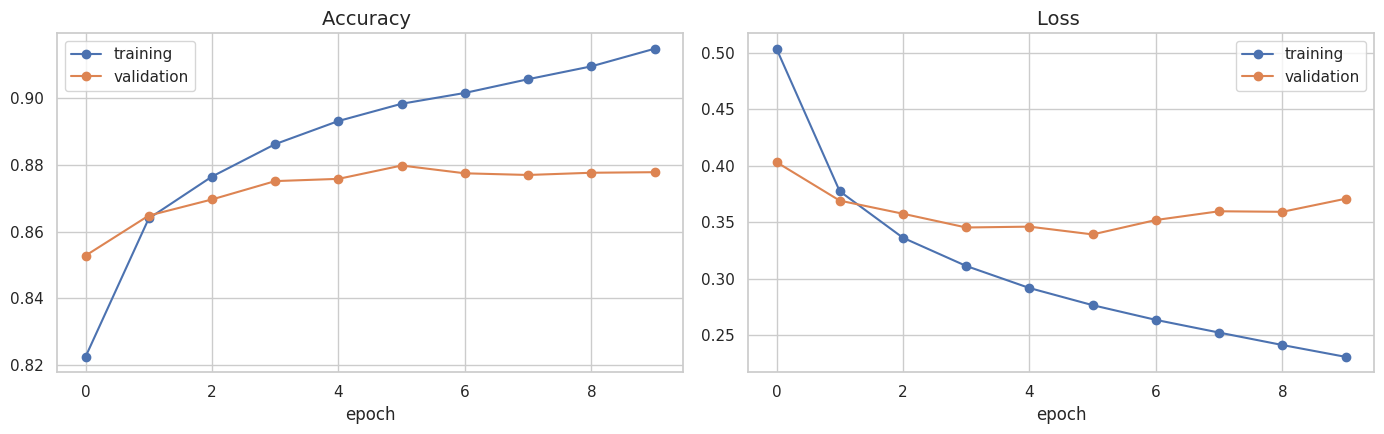

In [12]:
def plot_history(h, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    axes[0].plot(h.history["accuracy"], "o-", label="training")
    axes[0].plot(h.history["val_accuracy"], "o-", label="validation")
    axes[0].set_title("Accuracy " + title, fontsize=14); axes[0].set_xlabel("epoch"); axes[0].legend()
    axes[1].plot(h.history["loss"], "o-", label="training")
    axes[1].plot(h.history["val_loss"], "o-", label="validation")
    axes[1].set_title("Loss " + title, fontsize=14); axes[1].set_xlabel("epoch"); axes[1].legend()
    plt.tight_layout(); plt.show()

plot_history(history)

🧠 **How to read them:**
- Both curves rising → still learning.
- Training keeps rising but validation goes flat → the model is starting to **memorise** (overfitting, Day 3).

### The final exam: the test set
10,000 images the model has **never seen**.

In [13]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.1%}   (random guessing = 10%)")

Test accuracy: 87.2%   (random guessing = 10%)


### Make predictions
The model outputs **10 probabilities** per image. The biggest one is its answer.

Probabilities for the first test image:
  T-shirt     0.000
  Trouser     0.000
  Pullover    0.000
  Dress       0.000
  Coat        0.000
  Sandal      0.000
  Shirt       0.000
  Sneaker     0.008
  Bag         0.000
  Ankle boot  0.992


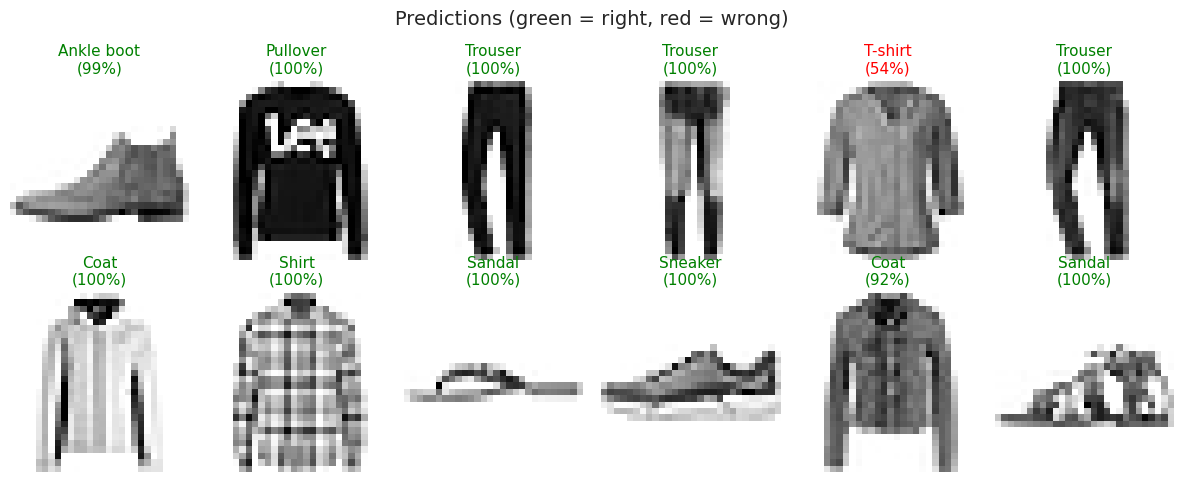

In [14]:
probs = model.predict(X_test[:12], verbose=0)
print("Probabilities for the first test image:")
for name, p in zip(class_names, probs[0]):
    print(f"  {name:11s} {p:.3f}")

preds = probs.argmax(axis=1)
plt.figure(figsize=(12, 5))
for i in range(12):
    plt.subplot(2, 6, i + 1)
    plt.imshow(X_test[i], cmap="gray_r"); plt.axis("off")
    ok = preds[i] == y_test[i]
    plt.title(f"{class_names[preds[i]]}\n({probs[i].max():.0%})", color="green" if ok else "red", fontsize=11)
plt.suptitle("Predictions (green = right, red = wrong)", fontsize=14)
plt.tight_layout(); plt.show()

✍️ **Exercise 2:** change the hidden layer to **Dense(32)** and then **Dense(512)** (re-run from the "Build" cell). How do the number of weights and the test accuracy change?

> 🛑 **End of the first hands-on block.** Go back to the slides.

---
## Part 4 · What does the network get wrong?
Overall accuracy hides a lot. Let's check **each clothing type** with a **confusion matrix** (Day 2).

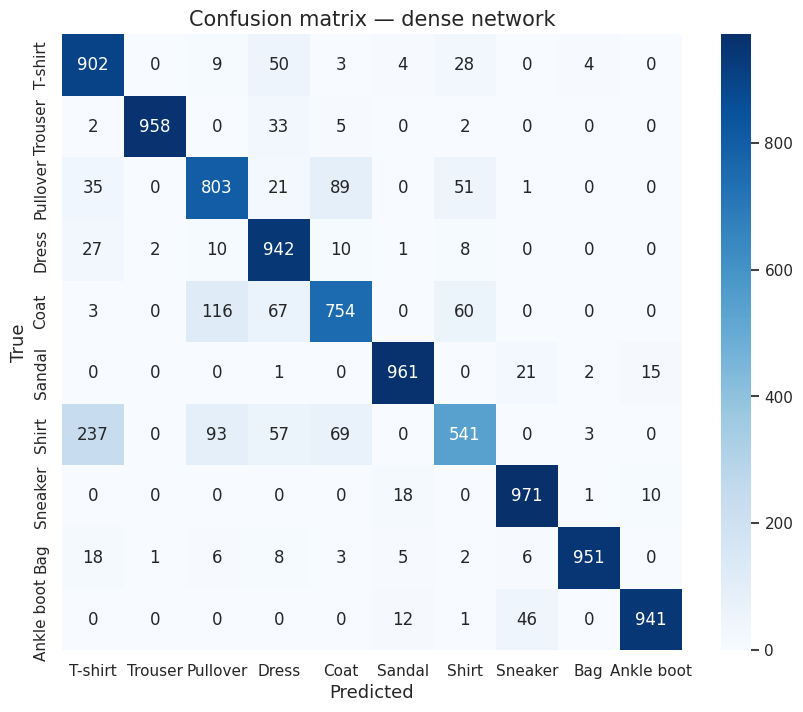

In [15]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted", fontsize=13); plt.ylabel("True", fontsize=13)
plt.title("Confusion matrix — dense network", fontsize=15)
plt.show()

In [16]:
per_class = cm.diagonal() / cm.sum(axis=1)
order = np.argsort(per_class)[::-1]
for i in order:
    print(f"{class_names[i]:11s} {per_class[i]:.1%}")

Sneaker     97.1%
Sandal      96.1%
Trouser     95.8%
Bag         95.1%
Dress       94.2%
Ankle boot  94.1%
T-shirt     90.2%
Pullover    80.3%
Coat        75.4%
Shirt       54.1%


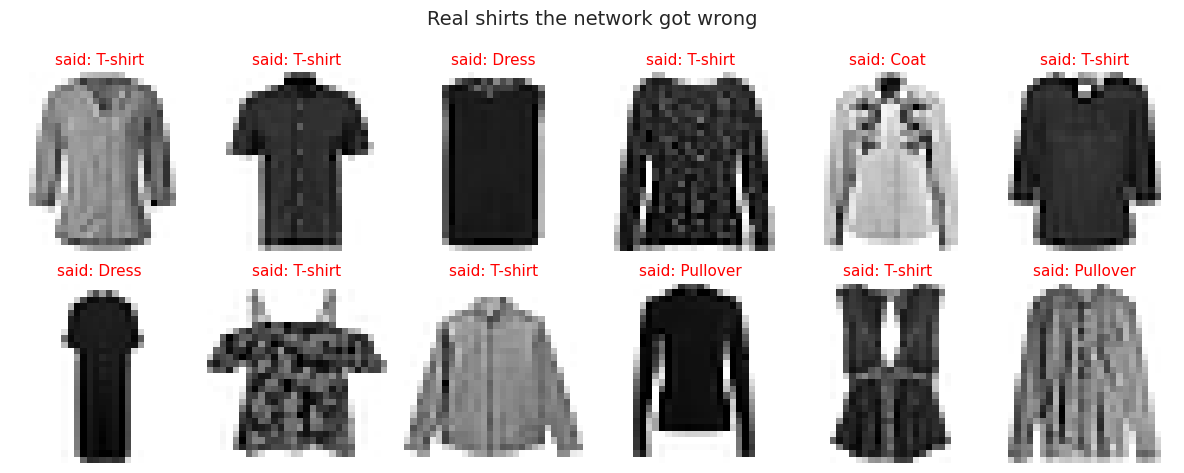

In [17]:
# Show some shirts the network got wrong
wrong = np.where((y_test == 6) & (y_pred != 6))[0][:12]
plt.figure(figsize=(12, 5))
for k, i in enumerate(wrong):
    plt.subplot(2, 6, k + 1)
    plt.imshow(X_test[i], cmap="gray_r"); plt.axis("off")
    plt.title("said: " + class_names[y_pred[i]], fontsize=11, color="red")
plt.suptitle("Real shirts the network got wrong", fontsize=14)
plt.tight_layout(); plt.show()

🧠 Could **you** tell these shirts from T-shirts at 28×28 pixels? Shirts are mostly confused with T-shirts, pullovers and coats — they really do look alike.
The CNN in Notebook 2 will do much better on these.

---
## Part 5 · Overfitting and dropout
Let's build a **much bigger** network (two layers of 512 neurons, ~670,000 weights) and train it for **30 epochs**. Big network + long training = memorising risk.

⏳ About 1 minute each on GPU (2–3 on CPU). While it trains: **which curve do you expect to go up?**

No dropout   -> train acc 96.7%  val acc 88.8%


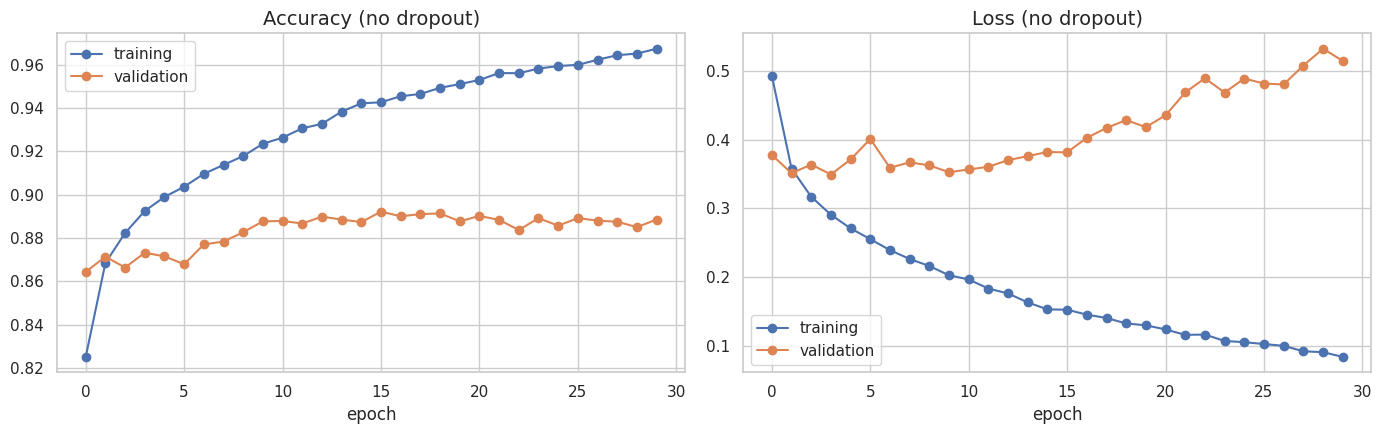

In [18]:
def big_model(dropout=0.0):
    keras.utils.set_random_seed(42)
    m = keras.Sequential([keras.Input(shape=(28, 28)), layers.Flatten()])
    for _ in range(2):
        m.add(layers.Dense(512, activation="relu"))
        if dropout > 0:
            m.add(layers.Dropout(dropout))   # switch off a random 30% of neurons at every training step
    m.add(layers.Dense(10, activation="softmax"))
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

big = big_model(dropout=0.0)
h_big = big.fit(X_train, y_train, epochs=30, batch_size=128, validation_split=0.1, verbose=0)
print("No dropout   -> train acc %.1f%%  val acc %.1f%%" % (100 * h_big.history["accuracy"][-1], 100 * h_big.history["val_accuracy"][-1]))
plot_history(h_big, "(no dropout)")

🧠 Look at the **validation loss** (right plot): it drops, then **climbs back up** while training loss keeps falling. The network is becoming confidently wrong on new images — that's **overfitting**.

### The fix: Dropout
**Dropout(0.3)** randomly switches off 30% of the neurons at every training step, so no neuron can rely on a particular partner. Like a football team practising with random players missing — everyone has to learn to play.

With dropout -> train acc 92.1%  val acc 89.4%


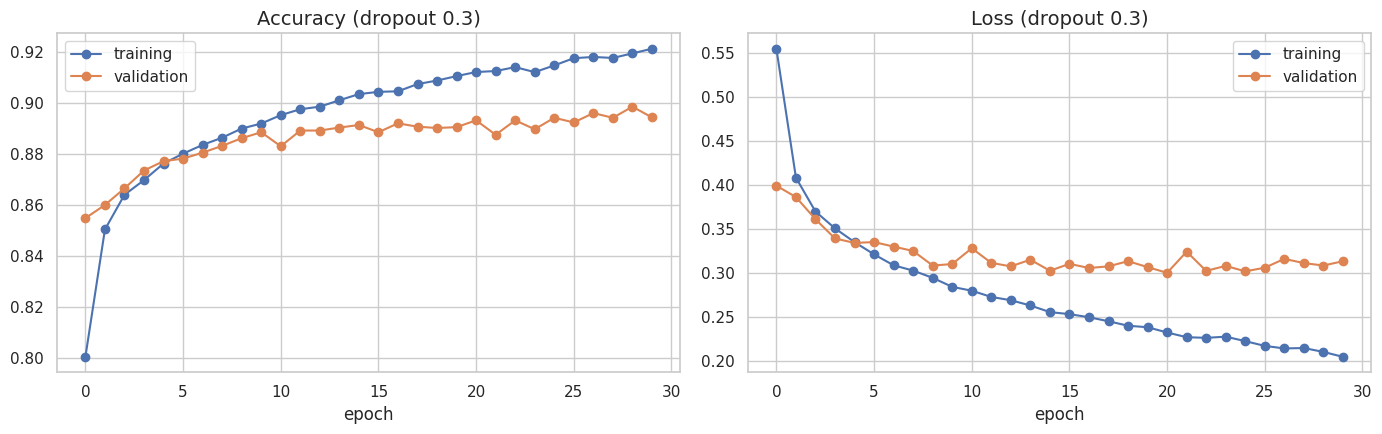

In [19]:
drop = big_model(dropout=0.3)
h_drop = drop.fit(X_train, y_train, epochs=30, batch_size=128, validation_split=0.1, verbose=0)
print("With dropout -> train acc %.1f%%  val acc %.1f%%" % (100 * h_drop.history["accuracy"][-1], 100 * h_drop.history["val_accuracy"][-1]))
plot_history(h_drop, "(dropout 0.3)")

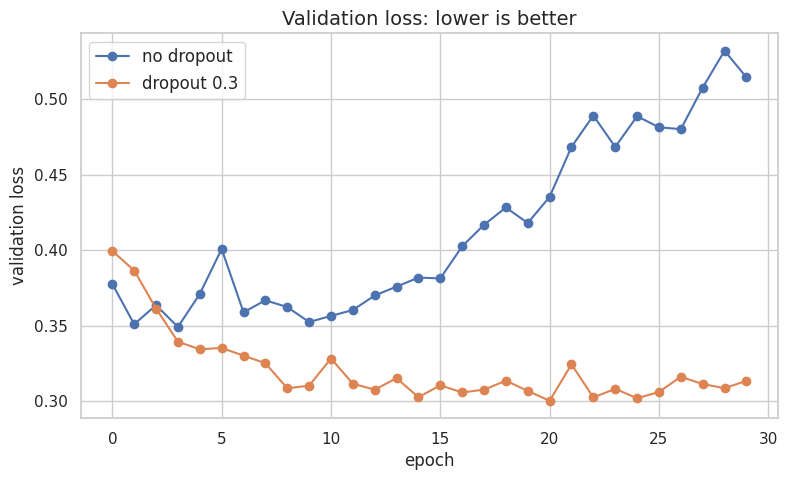

No dropout   test accuracy: 88.5%
Dropout 0.3  test accuracy: 89.1%


In [20]:
plt.figure(figsize=(9, 5))
plt.plot(h_big.history["val_loss"], "o-", label="no dropout")
plt.plot(h_drop.history["val_loss"], "o-", label="dropout 0.3")
plt.xlabel("epoch"); plt.ylabel("validation loss"); plt.legend(fontsize=12)
plt.title("Validation loss: lower is better", fontsize=14); plt.show()

for name, m in [("No dropout", big), ("Dropout 0.3", drop)]:
    print(f"{name:12s} test accuracy: {m.evaluate(X_test, y_test, verbose=0)[1]:.1%}")

✍️ **Exercise 3:** another popular fix is **EarlyStopping** — stop automatically when validation loss stops improving. Train `big_model(0.0)` again, adding
`callbacks=[keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]` to `fit`. At which epoch does it stop?

---
## ✅ Summary
- A neuron = weighted sum + bias → activation.
- A network = layers of neurons; training finds the weights using loss + optimizer, epoch by epoch.
- Always plot the training curves; a rising validation loss means overfitting.
- Dropout and early stopping fight overfitting.
- Dense networks ignore the picture's shape — next notebook: **CNNs**.

---
## Solutions

In [ ]:
# Exercise 1
w2 = np.array([2, 3, -6])
print("Exam weight -6:", np.dot(w2, x) + b, "-> stay home")
print("Not sunny     :", np.dot(w, np.array([0, 1, 1])) + b, "-> stay home")

In [ ]:
# Exercise 2 (Dense 32): 784*32+32 + 32*10+10 = 25,450 weights, usually ~85-86% test accuracy.
# Dense 512: 407,050 weights, usually ~88-89%. Bigger helps a little, but costs more and overfits sooner.
small = keras.Sequential([keras.Input(shape=(28, 28)), layers.Flatten(),
                          layers.Dense(32, activation="relu"), layers.Dense(10, activation="softmax")])
small.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
small.fit(X_train, y_train, epochs=10, validation_split=0.1, verbose=0)
print("Dense 32 weights:", small.count_params(), " test acc: %.1f%%" % (100 * small.evaluate(X_test, y_test, verbose=0)[1]))

In [ ]:
# Exercise 3
es_model = big_model(0.0)
h_es = es_model.fit(X_train, y_train, epochs=30, batch_size=128, validation_split=0.1, verbose=0,
                    callbacks=[keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)])
print("Stopped after", len(h_es.history["loss"]), "epochs; test acc %.1f%%" % (100 * es_model.evaluate(X_test, y_test, verbose=0)[1]))